In [2]:
! pip install faiss-cpu


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\VİCTUS\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [2]:
import urllib.request as request 
import tarfile 
import numpy as np 
import os 
import faiss 
import matplotlib.pyplot as plt 
import time 
import psutil 
import tempfile 
# Sabitler
sift_url = "ftp://ftp.irisa.fr/local/texmex/corpus/sift.tar.gz"
sift_archive = "sift.tar.gz"
sift_dir = "sift"


base_file = f"{sift_dir}/sift_base.fvecs"
query_file = f"{sift_dir}/sift_query.fvecs"
gt_file = f"{sift_dir}/sift_groundtruth.ivecs"
len_file = f"{sift_dir}/sift_learn.fvecs" 


# İndir ve çıkar 
if  not os.path.exists(sift_archive): 
    print ( "sift.tar.gz indiriliyor..." )
    request.urlretrieve(sift_url, sift_archive) 
if  not os.path.exists(base_file): 
    print ( "Arşiv çıkarılıyor..." ) 
    with tarfile. open (sift_archive, "r:gz" ) as tar: 
        tar.extractall()

In [3]:
# Yükleyiciler 
def read_fvecs(filename): 
    with open(filename, "rb") as f: 
        d = np.fromfile(f, dtype=np.int32, count=1)[0] 
        f.seek(0) 
        data = np.fromfile(f, dtype=np.float32) 
        return data.reshape(-1, d + 1)[:, 1:]
def read_ivecs(filename): 
    with open(filename, "rb") as f: 
        d = np.fromfile(f, dtype=np.int32, count=1)[0] 
        f.seek(0) 
        data = np.fromfile(f, dtype=np.int32) 
        return data.reshape(-1, d + 1)[:, 1:]

 
# Verileri yükle 
xb = read_fvecs(base_file) 
xq = read_fvecs(query_file) 
I_true = read_ivecs(gt_file) 
xt = read_fvecs(len_file) 
print("SIFT1M Veri Kümesi Yüklendi") 
print(f"Temel: {xb.shape}, Sorgu: {xq.shape}, Doğru Değer: {I_true.shape} , Öğrenme: {xt.shape}")

SIFT1M Veri Kümesi Yüklendi
Temel: (1000000, 128), Sorgu: (10000, 128), Doğru Değer: (10000, 100) , Öğrenme: (100000, 128)


In [ ]:
process = psutil.Process(os.getpid())

# Index oluşturulmadan hemen önceki RAM durumu
ram_before_flat = process.memory_info().rss / (1024 ** 2)

# FAISS index’i oluşturmak için gerekli olan vektör boyutu
d = xb.shape[1]

#İnşa süresi
start_build = time.time()

# IndexFlatL2: brute-force arama yapar
index_flat = faiss.IndexFlatL2(d)

# Veri tabanı vektörleri index’e eklenir
index_flat.add(xb)
end_build = time.time()
build_time_flat = end_build - start_build

# Index oluşturulduktan sonraki RAM durumu
ram_after_flat = process.memory_info().rss / (1024 ** 2)

print("-" * 30)
print(f"[FLAT]BELLEK ÖLÇÜMLERİ:")
print(f"[FLAT]Index Öncesi RAM: {ram_before_flat:.2f} MB")
print(f"[FLAT]Index Sonrası RAM: {ram_after_flat:.2f} MB")
print(f"[FLAT]İnşa Süresi: {build_time_flat:.6f} saniye")
print("-" * 30)


# Index içinde kaç vektör olduğu kontrol edilir
print("Dizindeki vektör sayısı:", index_flat.ntotal)

# QUERY (Sorgu ayarları)
#Her sorgu için kaç komşu aranacak
k = 100

#Kaç tane sorgu yapılacak ona bakar 
num_queries_to_test = len(xq)
print(f"\nIndexFlatL2 ile {num_queries_to_test} sorgu aranıyor...")

# QUERY LATENCY (Sorgu süresi)
start_time = time.time()

D_flat, I_flat = index_flat.search(
    xq[:num_queries_to_test],
    k
)

end_time = time.time()

query_time_flat = end_time - start_time
avg_latency = query_time_flat / num_queries_to_test

print(f"Toplam Query Süresi: {query_time_flat:.6f} saniye")
print(f"Ortalama Query Latency: {avg_latency:.6f} saniye/sorgu")

# RECALL@10
recall_flat = (
    np.any(I_flat[:, :10] == I_true[:num_queries_to_test, 0:1], axis=1)
).mean()

print(f"\nIndexFlatL2 için Recall@10: {recall_flat:.4f}")


#CPU kullanım miktarı
cpu_usage=psutil.cpu_percent()
print(f"Süreç sonunda CPU kullanımı:{cpu_usage:.2f}")



------------------------------
[FLAT]BELLEK ÖLÇÜMLERİ:
[FLAT]Index Öncesi RAM: 1413.69 MB
[FLAT]Index Sonrası RAM: 1865.52 MB
[FLAT]İnşa Süresi: 0.294868 saniye
------------------------------
Dizindeki vektör sayısı: 1000000

IndexFlatL2 ile 10000 sorgu aranıyor...
Toplam Query Süresi: 19.354219 saniye
Ortalama Query Latency: 0.001935 saniye/sorgu

IndexFlatL2 için Recall@10: 1.0000
Süreç sonunda CPU kullanımı:42.40


In [32]:
#nporbe analizi için gerekli fonksiyon
def nprobe_analizi_yap(index, query_data, ground_truth, nprobe_list):
    results = []
    print(f"\n{'nprobe':<10} | {'Latency (ms)':<15} | {'Recall@10':<10}")
    print("-" * 40)
    
    for np_val in nprobe_list:
        index.nprobe = np_val
        
        start = time.time()
        _, I = index.search(query_data, 100) # k=100
        end = time.time()
        
        latency = ((end - start) / len(query_data)) * 1000 # ms cinsinden daha okunur
        recall = (np.any(I[:, :10] == ground_truth[:, 0:1], axis=1)).mean()
        
        results.append((np_val, latency, recall))
        print(f"{np_val:<10} | {latency:<15.4f} | {recall:<10.4f}")
    
    return results

In [33]:
process = psutil.Process(os.getpid())

# Index oluşturulmadan hemen önceki RAM durumu
ram_before_ivf= process.memory_info().rss / (1024 ** 2)

# --- IndexIVFFlat ---
nlist = 1000 # Hücre sayısı
quantizer = faiss.IndexFlatL2(d)
index_ivf = faiss.IndexIVFFlat(quantizer, d, nlist)

# İNŞA SÜRESİ (Eğitim gerektirir.)
start_build = time.time()
index_ivf.train(xt)  # 'xt' öğrenme kümesi ile eğitilir
index_ivf.add(xb)    # 1M vektör eklenir
end_build = time.time()

build_time_ivf=end_build - start_build

ram_after_ivf=process.memory_info().rss / (1024 ** 2)

print("-" * 30)
print(f"[IVF]BELLEK ÖLÇÜMLERİ:")
print(f"[IVF]Index Öncesi RAM: {ram_before_ivf:.2f} MB")
print(f"[IVF]Index Sonrası RAM: {ram_after_ivf:.2f} MB")
print(f"\n[IVF] Build Time: {build_time_ivf:.6f} saniye")
print("-" * 30)


# SORGU SÜRESİ
index_ivf.nprobe = 10 # Kaç hücre taranacak?
start_search = time.time()
D_ivf, I_ivf = index_ivf.search(xq, k)
end_search = time.time()

query_time_ivf = end_search - start_search
lat_mean_ivf=query_time_ivf/len(xq)
print(f"[IVF] Ortalama Latency: {lat_mean_ivf:.6f} saniye/sorgu")

# RECALL@10
recall_ivf = (np.any(I_ivf[:, :10] == I_true[:, 0:1], axis=1)).mean()
print(f"[IVF] Recall@10: {recall_ivf:.4f}")

#CPU kullanım miktarı
cpu_usage=psutil.cpu_percent()
print(f"Süreç sonunda CPU kullanımı:{cpu_usage:.2f}")

#nlist değeri
print(f"IVFFlat'da kullanılan cluster sayısı:{nlist}")

# Deney değerlerinin belirlenmesi ve fonksiyonun çağırılması
test_degerleri = [1, 5, 10, 50, 100]
analiz_sonuclari = nprobe_analizi_yap(index_ivf, xq, I_true, test_degerleri)

------------------------------
[IVF]BELLEK ÖLÇÜMLERİ:
[IVF]Index Öncesi RAM: 1882.98 MB
[IVF]Index Sonrası RAM: 2541.58 MB

[IVF] Build Time: 3.412550 saniye
------------------------------
[IVF] Ortalama Latency: 0.000211 saniye/sorgu
[IVF] Recall@10: 0.9163
Süreç sonunda CPU kullanımı:12.40
IVFFlat'da kullanılan cluster sayısı:1000

nprobe     | Latency (ms)    | Recall@10 
----------------------------------------
1          | 0.0229          | 0.4651    
5          | 0.1084          | 0.8206    
10         | 0.2101          | 0.9163    
50         | 0.9904          | 0.9962    
100        | 1.9010          | 0.9993    


In [34]:
process = psutil.Process(os.getpid())

# Index oluşturulmadan hemen önceki RAM durumu
ram_before_hnsw= process.memory_info().rss / (1024 ** 2)


# --- IndexHNSWFlat ---
M = 32 # Her düğümün kuracağı bağ sayısı
index_hnsw = faiss.IndexHNSWFlat(d, M)

# İNŞA SÜRESİ
start_build = time.time()
index_hnsw.add(xb) # HNSW eğitim gerektirmez, direkt eklenir
end_build = time.time()

build_time_hnsw=end_build - start_build

ram_after_hnsw=process.memory_info().rss / (1024 ** 2)

print("-" * 30)
print(f"[HNSW]BELLEK ÖLÇÜMLERİ:")
print(f"[HNSW]Index Öncesi RAM: {ram_before_hnsw:.2f} MB")
print(f"[HNSW]Index Sonrası RAM: {ram_after_hnsw:.2f} MB")
print(f"\n[HNSW] Build Time: {build_time_hnsw:.6f} saniye")
print("-" * 30)


# SORGU SÜRESİ
start_search = time.time()
D_hnsw, I_hnsw = index_hnsw.search(xq, k)
end_search = time.time()

query_time_hnsw = end_search - start_search
lat_mean_hnsw=query_time_hnsw/len(xq)
print(f"[HNSW] Ortalama Latency: {lat_mean_hnsw:.6f} saniye/sorgu")

# RECALL@10
recall_hnsw = (np.any(I_hnsw[:, :10] == I_true[:, 0:1], axis=1)).mean()
print(f"[HNSW] Recall@10: {recall_hnsw:.4f}")

#CPU kullanım miktarı
cpu_usage=psutil.cpu_percent()
print(f"Süreç sonunda CPU kullanımı:{cpu_usage:.2f}")

------------------------------
[HNSW]BELLEK ÖLÇÜMLERİ:
[HNSW]Index Öncesi RAM: 2559.58 MB
[HNSW]Index Sonrası RAM: 2474.88 MB

[HNSW] Build Time: 55.189529 saniye
------------------------------
[HNSW] Ortalama Latency: 0.000031 saniye/sorgu
[HNSW] Recall@10: 0.9109
Süreç sonunda CPU kullanımı:75.60


In [35]:
import pandas as pd
#TÜM SONUÇLARIN TABLOSU
data={
   "Index Tipi": ["FlatL2", "IVFFlat", "HNSW"],
    "Inşa Süresi (s)": [build_time_flat, build_time_ivf, build_time_hnsw],
    "Ortalama Latency (s)": [avg_latency,lat_mean_ivf, lat_mean_hnsw],
    "Recall@10": [recall_flat, recall_ivf, recall_hnsw],
    "RAM Kullanımı(Önce)":[ram_before_flat,ram_before_ivf,ram_before_hnsw],
    "RAM Kullanımı(Sonra)":[ram_after_flat,ram_after_ivf,ram_after_hnsw]
}
df=pd.DataFrame(data)
print("PERFORMANS ÖZET TABLOSU")
print(df.to_string(index=False))

PERFORMANS ÖZET TABLOSU
Index Tipi  Inşa Süresi (s)  Ortalama Latency (s)  Recall@10  RAM Kullanımı(Önce)  RAM Kullanımı(Sonra)
    FlatL2         0.294868              0.001935     1.0000          1413.687500           1865.523438
   IVFFlat         3.412550              0.000211     0.9163          1882.984375           2541.582031
      HNSW        55.189529              0.000031     0.9109          2559.578125           2474.875000


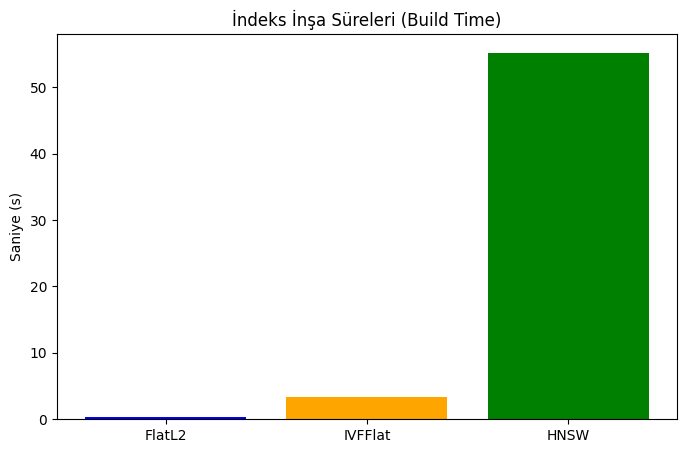

In [36]:
#İNŞA SÜRESİ KARŞILAŞTIRILMASI

labels = ['FlatL2', 'IVFFlat', 'HNSW']
build_times = [build_time_flat, build_time_ivf, build_time_hnsw]

plt.figure(figsize=(8, 5))
plt.bar(labels, build_times, color=['blue', 'orange', 'green'])
plt.ylabel('Saniye (s)')
plt.title('İndeks İnşa Süreleri (Build Time)')
plt.show()

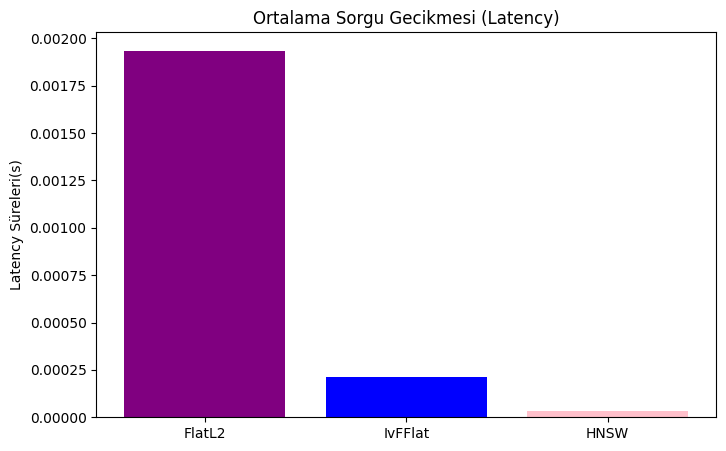

In [37]:
#LATENCY SÜRE KARŞILAŞTIRILMASI
labels=["FlatL2","IvFFlat","HNSW"]
latencies = [avg_latency, query_time_ivf/len(xq), query_time_hnsw/len(xq)]

plt.figure(figsize=(8, 5))
plt.bar(labels,latencies,color=['purple','blue','pink'])
plt.ylabel("Latency Süreleri(s)")
plt.title("Ortalama Sorgu Gecikmesi (Latency)")
plt.show()


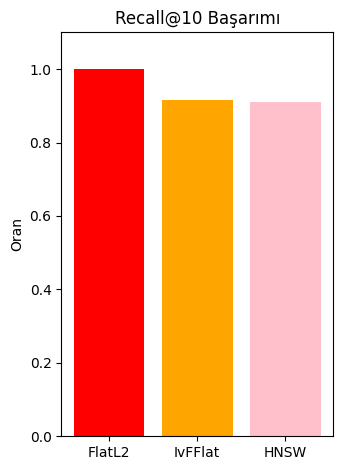

In [38]:
#RECALL@10 DEĞER KARŞILAŞTIRMALARI
labels=["FlatL2","IvFFlat","HNSW"]
recalls = [recall_flat, recall_ivf, recall_hnsw]

plt.subplot(1, 2, 2)
plt.bar(labels, recalls, color=['red', 'orange', 'pink'])
plt.ylim(0, 1.1)
plt.title('Recall@10 Başarımı')
plt.ylabel('Oran')
plt.tight_layout()
plt.show()